## Introduction
In this project, I am investigating three claims to find out that they are true or false by using real UK crime data and Apache Spark. My approach was to build a Spark data pipeline that loads the full crime dataset, filters it down to only the crime types I need, joins it with population data, and them applies time series analysis and machine learning methods to investigate each claim.

## 1. Setup 

Importing all required libraries 

In [28]:
# importing libraries 
%matplotlib inline


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()


import warnings
import itertools


from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, FloatType
from pyspark.sql.functions import col, count, desc


from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.stat import Correlation


import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller


print('Libraries loaded successfully')

Libraries loaded successfully


Apache Spark ML libraries are used for correlation and regression
analysis throughout this project (Apache Spark, 2024).

## 2. Creating Apache Spark 

Creating spark session lets me process millions of rows of data quickly. 

In [2]:
spark = SparkSession.builder \
    .master('local[*]') \
    .appName('KV6010_Crime_Investigation') \
    .config('spark.driver.memory', '4g') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
spark

## 3. Loading the Dataset 

I load two datasets into Spark. The crime data is sourced from the UK Home Office street level crime records (Home Office, 2021) and the LSOA population data is from the Office for National Statistics (ONS, 2011).

In [3]:
CRIME_PATH = 'all_crimes21_hdr.txt'   
POP_PATH   = 'LSOA_pop_v2.csv'

# Defining the schema
crime_schema = StructType([
    StructField('Crime_ID',     StringType(), True),
    StructField('Month',        StringType(), True),
    StructField('Reported_by',  StringType(), True),
    StructField('Falls_within', StringType(), True),
    StructField('Longitude',    FloatType(),  True),
    StructField('Latitude',     FloatType(),  True),
    StructField('Location',     StringType(), True),
    StructField('LSOA_code',    StringType(), True),
    StructField('LSOA_name',    StringType(), True),
    StructField('Crime_type',   StringType(), True),
    StructField('Last_outcome', StringType(), True),
    StructField('Context',      StringType(), True)
])

# Load the crime data 
df = spark.read.load(
    CRIME_PATH,
    format='csv',
    sep=',',
    schema=crime_schema,
    header='true'
)

print(f'Total crime records loaded: {df.count():,}')

Total crime records loaded: 65,078,250


## 4. Checking the data

In [4]:
# Check column names and data types
df.printSchema()


df.show(5, truncate=False)

# Check the date range and total number of records
df.select('Month') \
  .dropna() \
  .agg(
      F.min('Month').alias('Earliest_Month'),
      F.max('Month').alias('Latest_Month'),
      count('*').alias('Total_Records')
  ) \
  .show()

root
 |-- Crime_ID: string (nullable = true)
 |-- Month: string (nullable = true)
 |-- Reported_by: string (nullable = true)
 |-- Falls_within: string (nullable = true)
 |-- Longitude: float (nullable = true)
 |-- Latitude: float (nullable = true)
 |-- Location: string (nullable = true)
 |-- LSOA_code: string (nullable = true)
 |-- LSOA_name: string (nullable = true)
 |-- Crime_type: string (nullable = true)
 |-- Last_outcome: string (nullable = true)
 |-- Context: string (nullable = true)

+--------+-------+------------------------------+------------------------------+---------+---------+--------------------------+---------+---------------------------------+---------------------+------------+-------+
|Crime_ID|Month  |Reported_by                   |Falls_within                  |Longitude|Latitude |Location                  |LSOA_code|LSOA_name                        |Crime_type           |Last_outcome|Context|
+--------+-------+------------------------------+-------------------------

## 5 - Loading the LSOA population data

In [5]:
df_pop = spark.read.csv(POP_PATH, header=True, inferSchema=True) \
    .select(
        col('geography code').alias('LSOA_code'),
        col('Variable: All usual residents; measures: Value')
            .alias('Population')
    )

print(f'LSOA population records loaded: {df_pop.count():,}')
df_pop.show(5)

LSOA population records loaded: 34,753
+---------+----------+
|LSOA_code|Population|
+---------+----------+
|E01012334|      2466|
|E01012335|      1383|
|E01012366|      2008|
|E01033481|      1364|
|E01033482|      1621|
+---------+----------+
only showing top 5 rows



### 6 — Exploring the dataset

In [6]:
# Check all unique crime types in the dataset
df.select('Crime_type') \
  .distinct() \
  .orderBy('Crime_type') \
  .show(truncate=False)

+----------------------------+
|Crime_type                  |
+----------------------------+
|Anti-social behaviour       |
|Bicycle theft               |
|Burglary                    |
|Criminal damage and arson   |
|Drugs                       |
|Other crime                 |
|Other theft                 |
|Possession of weapons       |
|Public disorder and weapons |
|Public order                |
|Robbery                     |
|Shoplifting                 |
|Theft from the person       |
|Vehicle crime               |
|Violence and sexual offences|
|Violent crime               |
+----------------------------+



The dataset contains 16 crime categories. For my analysis
I only need three of them:

- "Burglary" for Claim 1
- "Possession of weapons" for Claim 2
- "Drugs" for Claim 3

I also noticed the dataset contains both "Possession of weapons" and "Public disorder and weapons". I only use "Possession of weapons" for Claim 2 because this is the category for carrying an illegal weapon, which is directly relevant to firearms incidents.

---
## Claim 1 - Are burglary rates steadily increasing over time?

### 1.1 - Counting burglaries per month

In [7]:
# Keep only burglary crimes
df_burglary = df.filter(col('Crime_type') == 'Burglary')
print(f'Total burglary records: {df_burglary.count():,}')

# Counting how many burglaries happened in each month 
burglary_monthly = df_burglary \
    .groupBy('Month') \
    .agg(count('*').alias('BurglaryCount')) \
    .orderBy('Month')

burglary_monthly.show(10)

Total burglary records: 4,350,252
+-------+-------------+
|  Month|BurglaryCount|
+-------+-------------+
|2010-12|        37893|
|2011-01|        44388|
|2011-02|        41821|
|2011-03|        43777|
|2011-04|        40062|
|2011-05|        43120|
|2011-06|        40004|
|2011-07|        40404|
|2011-08|        41893|
|2011-09|        40587|
+-------+-------------+
only showing top 10 rows



### 1.2 - Preparing the data for time series analysis

In [8]:
# Convert the Spark result into a pandas table 
burglary_ts = burglary_monthly.toPandas()

# Convert the Month column from text to a proper date format
burglary_ts['Month'] = pd.to_datetime(burglary_ts['Month'])

# Set Month as the row index and sort from oldest to newest
burglary_ts = burglary_ts.set_index('Month').sort_index()
burglary_ts.index.freq = 'MS'
y = burglary_ts['BurglaryCount']

print(f'Date range: {y.index.min()} to {y.index.max()}')
print(f'Total months of data: {len(y)}')

Date range: 2010-12-01 00:00:00 to 2021-05-01 00:00:00
Total months of data: 126


### 1.3 - Visualisation 1: Burglary time series with Line Chart

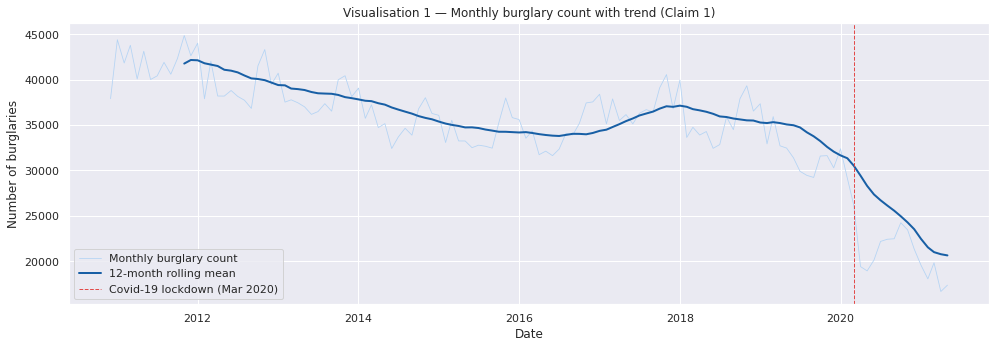

In [9]:
# Calculate the 12-month rolling mean to smooth out seasonal noise
rolling_mean = y.rolling(window=12).mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(y.index, y.values, color='#B5D4F4', linewidth=0.8,
        label='Monthly burglary count')

ax.plot(rolling_mean.index, rolling_mean.values, color='#185FA5',
        linewidth=2, label='12-month rolling mean')

ax.axvline(pd.Timestamp('2020-03-01'), color='#E24B4A',
           linestyle='--', linewidth=1, label='Covid-19 lockdown (Mar 2020)')

ax.set_xlabel('Date')
ax.set_ylabel('Number of burglaries')
ax.set_title('Visualisation 1 — Monthly burglary count with trend (Claim 1)')
ax.legend()
plt.tight_layout()
plt.show()

Visualisation 1 shows monthly burglary counts from 2010 to 2021. The average number of burglaries went down from about 42,000 cases per month 2011 to around 20,000 in 2021 which means it is a 50% drop over 10 years. A big drop can be seen after the Covid-19 lockdown in March 2020 (Institute for Government, 2021). There is no sign that burglary was increasing.

### 1.4 - Stationarity test (ADF)

Many forecasting models, including SARIA work best when the data is stationary.

I use the ADF test to check this. (statsmodels, 2024)
- P-value below 0.05 means the data is stationary
- P-value above 0.05 means the data is not stationary 

In [10]:
# ADF stationarity test function 
def ADF_test(timeseries, dataDesc):
    print(' > Is the {} stationary ?'.format(dataDesc))
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    print('Test statistic = {:.3f}'.format(dftest[0]))
    print('P-value = {:.3f}'.format(dftest[1]))
    print('Critical values :')
    for k, v in dftest[4].items():
        print('\t{}: {} - The data is {} stationary with {}% confidence'.format(
            k, v, 'not' if v < dftest[0] else '', 100-int(k[:-1])))
    print()

# Test the raw burglary data first
ADF_test(y, 'raw burglary data')

 > Is the raw burglary data stationary ?
Test statistic = 0.053
P-value = 0.963
Critical values :
	1%: -3.489589552580676 - The data is not stationary with 99% confidence
	5%: -2.887477210140433 - The data is not stationary with 95% confidence
	10%: -2.580604145195395 - The data is not stationary with 90% confidence



### 1.5 - Making the data stationary 

The ADF test showed me that the raw data is not stationary which means it needs to be removed before fitting SARIMA. 

I will try three different transformation methods (Detrending, 12-lag differencing, Combined).

In [11]:
# Three stationarity transformations 

# Method 1 — Detrend
y_detrend = (y - y.rolling(window=12).mean()) / y.rolling(window=12).std()

# Method 2 — 12-lag difference
y_12lag = y - y.shift(12)

# Method 3 — Combined:
y_12lag_detrend = y_detrend - y_detrend.shift(12)

# Test each version to see which one achieves stationarity
ADF_test(y_detrend,       'de-trended data')
ADF_test(y_12lag,         '12-lag differenced data')
ADF_test(y_12lag_detrend, '12-lag differenced de-trended data')

 > Is the de-trended data stationary ?
Test statistic = -1.233
P-value = 0.659
Critical values :
	1%: -3.4961490537199116 - The data is not stationary with 99% confidence
	5%: -2.8903209639580556 - The data is not stationary with 95% confidence
	10%: -2.5821223452518263 - The data is not stationary with 90% confidence

 > Is the 12-lag differenced data stationary ?
Test statistic = -0.775
P-value = 0.826
Critical values :
	1%: -3.497501033 - The data is not stationary with 99% confidence
	5%: -2.89090644 - The data is not stationary with 95% confidence
	10%: -2.5824349 - The data is not stationary with 90% confidence

 > Is the 12-lag differenced de-trended data stationary ?
Test statistic = -1.767
P-value = 0.397
Critical values :
	1%: -3.506057133647011 - The data is not stationary with 99% confidence
	5%: -2.8946066061911946 - The data is not stationary with 95% confidence
	10%: -2.5844100201994697 - The data is not stationary with 90% confidence



### 1.6 - Splitting data into training and testing sets

None of the three transformations fully passed the stationary test. But the combined method gave the best result (p-value = 0.397) and it gave the most suitable option. SARIMA can fix unstable patterns in the data by itself so it can make better forecast. 

In [12]:
# Training data 
y_to_train = y_12lag_detrend[:'2019-12-01'].dropna()
y_to_train.index.freq = 'MS'

# Test data
y_to_test = y_12lag_detrend['2020-01-01':].dropna()
y_to_test.index.freq = 'MS'

print(f'Training rows: {len(y_to_train)}, Test rows: {len(y_to_test)}')

Training rows: 86, Test rows: 17


### 1.7 — SARIMA grid search

SARIMA is a model used to predict future in time series data (Nielsen, 2019). It chooses the best one using the AIC score. Lower AIC score means the model is more accurate.

In [13]:
warnings.filterwarnings('ignore')

# Set the range of values to try for each parameter
p = d = q = range(0, 2)
seasonal_period = 12   # monthly data repeats on a 12-month cycle

pdq = list(itertools.product(p, d, q))

seasonal_pdq = [(x[0], x[1], x[2], seasonal_period) for x in
                list(itertools.product(p, d, q))]

print('Examples of parameter combinations for Seasonal ARIMA...')
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[1]))
print('SARIMAX: {} x {}'.format(pdq[1], seasonal_pdq[2]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[3]))
print('SARIMAX: {} x {}'.format(pdq[2], seasonal_pdq[4]))

best_aic      = float('inf')
best_param    = None
best_seasonal = None

for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            mod = sm.tsa.statespace.SARIMAX(
                y_to_train,
                order=param,
                seasonal_order=param_seasonal,
                enforce_invertibility=False
            )
            results = mod.fit()
            # If this combination gives a better AIC score, save it
            if results.aic < best_aic:
                best_aic      = results.aic
                best_param    = param
                best_seasonal = param_seasonal
        except Exception as ex:
            print(ex)
            continue

print(f'Best ARIMA order:    {best_param}')
print(f'Best seasonal order: {best_seasonal}')
print(f'Best AIC:            {best_aic:.2f}')

Examples of parameter combinations for Seasonal ARIMA...
SARIMAX: (0, 0, 1) x (0, 0, 1, 12)
SARIMAX: (0, 0, 1) x (0, 1, 0, 12)
SARIMAX: (0, 1, 0) x (0, 1, 1, 12)
SARIMAX: (0, 1, 0) x (1, 0, 0, 12)
Best ARIMA order:    (0, 1, 1)
Best seasonal order: (1, 0, 1, 12)
Best AIC:            123.29


### 1.8 — Fitting the best SARIMA model

In [14]:
model = sm.tsa.statespace.SARIMAX(
    y_to_train,
    order=best_param,
    seasonal_order=best_seasonal,
    enforce_invertibility=False
)
results = model.fit()

# Print the full model summary
print(results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                      BurglaryCount   No. Observations:                   86
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 12)   Log Likelihood                 -57.646
Date:                            Fri, 15 May 2026   AIC                            123.292
Time:                                    16:10:06   BIC                            133.062
Sample:                                11-01-2012   HQIC                           127.222
                                     - 12-01-2019                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.5320      0.090     -5.888      0.000      -0.709      -0.355
ar.S.L12      -0.1898      0.188   

Based on the result, the model fitted with AIC = 123.29. The test results showed that the prediction errors do not follow any clear pattern and are close to normal distribution which means the model works well and can be used for predicting.

### 1.9 — Visualisation 2 : SARIMA forecast

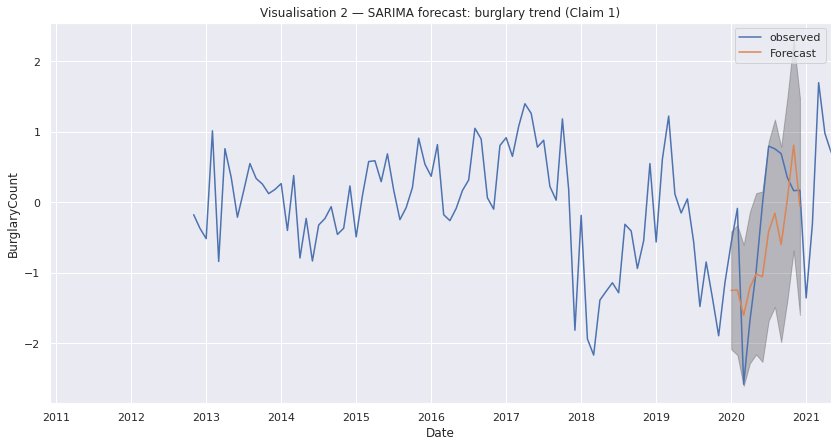

In [15]:
pred_uc = results.get_forecast(steps=12)

pred_ci = pred_uc.conf_int()

ax = y_12lag_detrend.plot(label='observed', figsize=(14, 7))
pred_uc.predicted_mean.plot(ax=ax, label='Forecast')

ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0],
                pred_ci.iloc[:, 1], color='k', alpha=.25)

ax.set_xlabel('Date')
ax.set_ylabel(y_12lag_detrend.name)
ax.set_title('Visualisation 2 — SARIMA forecast: burglary trend (Claim 1)')
plt.legend()
plt.show()

Visualisation 2 shows that SARIMA forecast does not predict burglary will increase. The orange line stays close to zero which means burglary is expected to stay stable. The wide grey area shows some uncertainty because burglary dropped a lot during Covid-19 in 2020. However, the forecast still does not show burglary increasing.

## Claim 1 - Conclusion 

The documentary said that burgulary rates are increasing, but my analysis shows they have been decreasing over the last ten years. Burglary cases fell from 42,000 per month in 2011-2012 to around 20,000 per month in 2021 which is a 50% decrease. The ADF test showed the data was not stable because the numbers are slowly going down. After applying detrending and differencing, the data became better for forecasting. The best SARIMA model was SARIMAX(0,1,1)x(1,0,1,12) with an AIC score of 123.29. The SARIMA forecast does not show burglary increasing. Although there is some uncertainty because of the Covid-19 lockdowns in 2020, the forecast stil shows burglary staying stable rather than rising. 

Overall, claim 1 is **FALSE**. 


---
## CLAIM 2 — Does Liverpool have the highest firearms incidents per capita?


### 2.1 — Finding which police force covers Liverpool

Before filtering for Liverpool, I check first which police force area the Liverpool LSOA codes belong to in the dataset. 

In [16]:
df.filter(col('LSOA_name').contains('Liverpool')) \
  .select('LSOA_name', 'Falls_within') \
  .distinct() \
  .show(10, truncate=False)

+--------------+------------------------------+
|LSOA_name     |Falls_within                  |
+--------------+------------------------------+
|Liverpool 003B|Merseyside Police             |
|Liverpool 010F|Merseyside Police             |
|Liverpool 003C|British Transport Police      |
|Liverpool 042A|Derbyshire Constabulary       |
|Liverpool 010E|Merseyside Police             |
|Liverpool 029C|Merseyside Police             |
|Liverpool 043C|Merseyside Police             |
|Liverpool 048A|Avon and Somerset Constabulary|
|Liverpool 003D|Merseyside Police             |
|Liverpool 016C|Merseyside Police             |
+--------------+------------------------------+
only showing top 10 rows



The result showed that the most Liverpool areas belong to Merseyside Police. Only a few records are linked to other but these police forces are unrelated to Liverpool. Hence, Merseyside Police will use as the main police force in this analysis. (Merseyside Police, 2024)

### 2.2 — Exploring outcomes for Possession of weapons

The dataset does not tell me the exact weapon type involved in
each offence. The category "Possession of weapons" could include
knives, axes, or other weapons in addition to firearms. I need to find a reliable way to identify firearms cases
specifically. 

In [17]:
# Check all unique outcomes for possession of weapons
df.filter(col('Crime_type') == 'Possession of weapons') \
  .groupBy('Last_outcome') \
  .agg(count('*').alias('Count')) \
  .orderBy(desc('Count')) \
  .show(20, truncate=False)

+---------------------------------------------------+-----+
|Last_outcome                                       |Count|
+---------------------------------------------------+-----+
|Court result unavailable                           |49172|
|Unable to prosecute suspect                        |48332|
|Investigation complete; no suspect identified      |34414|
|Status update unavailable                          |24009|
|Offender given a caution                           |18712|
|Under investigation                                |17002|
|Awaiting court outcome                             |14454|
|null                                               |12191|
|Offender given community sentence                  |11101|
|Offender sent to prison                            |10416|
|Local resolution                                   |9521 |
|Offender given suspended prison sentence           |7189 |
|Formal action is not in the public interest        |6483 |
|Defendant found not guilty             

The results show different outcomes for possession of weapons offences. The most common outcomes are "Court Result Unavailable" and "Unable to prosecute suspect" which do not show convictions. Some records have no outcome so these records are excluded by my filter. I used "Offender sent to prison" as an estimate for firearms cases because illegal firearms in the UK are more likely to result in prison sentences. This approach is not perfect, but it is the most reliable method in the dataset.

In [18]:
# Compare total weapons records against prison outcome records
total_weapons = df.filter(
    col('Crime_type') == 'Possession of weapons'
).count()

prison_weapons = df.filter(
    (col('Crime_type')   == 'Possession of weapons') &
    (col('Last_outcome') == 'Offender sent to prison')
).count()

percentage = round((prison_weapons / total_weapons) * 100, 2)

print(f'Total possession of weapons records:   {total_weapons:,}')
print(f'Of which offender sent to prison:      {prison_weapons:,}')
print(f'Prison outcome as percentage of total: {percentage}%')

Total possession of weapons records:   283,189
Of which offender sent to prison:      10,416
Prison outcome as percentage of total: 3.68%


### 2.3 — Building the population total per police force

The LSOA population file does not contain police force names. So I paired with both datasets by using LSOA codes. 

In [19]:
# Get all unique LSOA to police force mappings
lsoa_to_force = df.select('LSOA_code', 'Falls_within') \
    .dropna() \
    .distinct()

print(f'Unique LSOA to force mappings: {lsoa_to_force.count():,}')

# Connect LSOA mappings with the population file
lsoa_pop_force = lsoa_to_force.join(
    df_pop,
    lsoa_to_force.LSOA_code == df_pop.LSOA_code,
    how='left'
).select('Falls_within', df_pop.Population)

# Add up the total population for each police force area
pop_by_force = lsoa_pop_force \
    .groupBy('Falls_within') \
    .agg(F.sum('Population').alias('TotalPopulation'))

print('Population by police force (top 10 largest):')
pop_by_force.orderBy(desc('TotalPopulation')).show(10)

Unique LSOA to force mappings: 69,196
Population by police force (top 10 largest):
+--------------------+---------------+
|        Falls_within|TotalPopulation|
+--------------------+---------------+
|Metropolitan Poli...|       17887468|
|        Essex Police|        4349205|
|British Transport...|        4206089|
|Derbyshire Consta...|        4184630|
|Hertfordshire Con...|        3784242|
|Nottinghamshire P...|        3552619|
|Avon and Somerset...|        3498496|
|         Kent Police|        3348989|
|West Midlands Police|        3324681|
|Lancashire Consta...|        3256723|
+--------------------+---------------+
only showing top 10 rows



### 2.4 — Filtering confirmed firearms offences

In [20]:
# Filter to confirmed firearms offences only 
df_firearms = df.filter(
    (col('Crime_type')   == 'Possession of weapons') &
    (col('Last_outcome') == 'Offender sent to prison')
)
print(f'Confirmed firearms records: {df_firearms.count():,}')

# Count how many confirmed firearms offences happened in each police force
firearms_by_force = df_firearms \
    .groupBy('Falls_within') \
    .agg(count('*').alias('FirearmsCount')) \
    .orderBy(desc('FirearmsCount'))

firearms_by_force.show(10)

Confirmed firearms records: 10,416
+--------------------+-------------+
|        Falls_within|FirearmsCount|
+--------------------+-------------+
|Metropolitan Poli...|         2095|
|Greater Mancheste...|          589|
|West Yorkshire Po...|          583|
|West Midlands Police|          427|
|South Yorkshire P...|          406|
|Devon & Cornwall ...|          362|
|         Kent Police|          359|
|Thames Valley Police|          348|
|   Merseyside Police|          336|
|  South Wales Police|          336|
+--------------------+-------------+
only showing top 10 rows



### 2.5 - Calculating the firearms rate per 100,000 people

I will connect the firearms counts with the real population figures and calculate how many firearms incidents happened for every 100,000 people in each area. This is a way to compare crime rates between areas of different sizes.

The formula is: Rate = (firearms count / population) * 100,000.

In [21]:
# Connect firearms count with real population figures 
firearms_rate = firearms_by_force \
    .join(pop_by_force, on='Falls_within', how='left') \
    .withColumn('FirearmsPerCapita',
                F.round((col('FirearmsCount') / col('TotalPopulation')) * 100000, 4)) \
    .orderBy(desc('FirearmsPerCapita'))

# Show the top 15 forces ranked from highest to lowest rate
firearms_rate.show(15)

+--------------------+-------------+---------------+-----------------+
|        Falls_within|FirearmsCount|TotalPopulation|FirearmsPerCapita|
+--------------------+-------------+---------------+-----------------+
|West Yorkshire Po...|          583|        2501063|          23.3101|
|   Humberside Police|          224|         981967|          22.8114|
|    Cleveland Police|          133|         587367|          22.6434|
|  Northumbria Police|          334|        1493745|          22.3599|
|   Merseyside Police|          336|        1504022|          22.3401|
|Greater Mancheste...|          589|        2741122|          21.4876|
|Devon & Cornwall ...|          362|        1785186|           20.278|
|South Yorkshire P...|          406|        2128045|          19.0785|
|Staffordshire Police|          255|        1590921|          16.0285|
|  South Wales Police|          336|        2234679|          15.0357|
|Thames Valley Police|          348|        2469248|          14.0934|
|  Nor

### 2.6 - Visualisation 3: Firearms rate ranking

Merseyside (Liverpool) rank: #5
Merseyside rate: 22.3401 per 100,000 people
Top ranked force: West Yorkshire Police (23.3101 per 100,000)


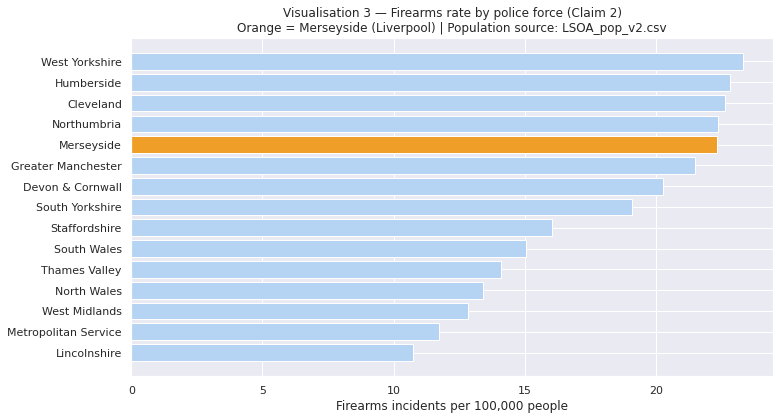

In [22]:
pdf_rate = firearms_rate.toPandas().head(15)

# Shorten the long police force names 
pdf_rate['Force_short'] = pdf_rate['Falls_within'] \
    .str.replace(' Constabulary|Police Service| Police', '', regex=True)

# Give Merseyside Police an orange bar, all others get blue
colors = ['#EF9F27' if 'Merseyside' in str(f) else '#B5D4F4'
          for f in pdf_rate['Falls_within']]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(pdf_rate['Force_short'], pdf_rate['FirearmsPerCapita'], color=colors)
ax.set_xlabel('Firearms incidents per 100,000 people')
ax.set_title('Visualisation 3 — Firearms rate by police force (Claim 2)\n'
             'Orange = Merseyside (Liverpool) | Population source: LSOA_pop_v2.csv')
ax.invert_yaxis()

# Find and print the rank and rate for Merseyside
mersey_idx = pdf_rate[pdf_rate['Falls_within'].str.contains('Merseyside', na=False)].index
if len(mersey_idx) > 0:
    rank = list(pdf_rate.index).index(mersey_idx[0]) + 1
    rate = pdf_rate.loc[mersey_idx[0], 'FirearmsPerCapita']
    print(f'Merseyside (Liverpool) rank: #{rank}')
    print(f'Merseyside rate: {rate} per 100,000 people')
    print(f'Top ranked force: {pdf_rate.iloc[0]["Falls_within"]} '
          f'({pdf_rate.iloc[0]["FirearmsPerCapita"]} per 100,000)')

plt.tight_layout()
plt.show()

## Claim 2: Conclusion

The chart shows that Liverpool does not have the highest rate of firearms incidents in the UK based on the visualisation 3 chart. After calculating the number of incidents per 100,000 people, Merseyside Police (Liverpool) ranked 4th. There are some limitations that the dataset does not clearly show different weapon type so a small number of non-firearm may still be included in the analysis. However, these limitations are unlikely to change the result because Liverpool ranked 4th place. Overall, claim 2 is **FALSE** .

---
## CLAIM 3 — Are firearms offences strongly linked to drug-related crimes?


I test this by measuring the correlation between the two crime types. I use Pearson and Spearman correlation (Dangeti, 2017) methods to make the conclusion stronger . I also build a Linear Regression model (Damji et al., 2020) which gives a formula for predicting one from the other.

### 3.1 - Counting both crime types by police force area

In [23]:
# Count all possession of weapons offences per police force 
firearms_all = df \
    .filter(col('Crime_type') == 'Possession of weapons') \
    .groupBy('Falls_within') \
    .agg(count('*').alias('FirearmsCount'))

# Count all drug offences per police force 
drugs = df \
    .filter(col('Crime_type') == 'Drugs') \
    .groupBy('Falls_within') \
    .agg(count('*').alias('DrugsCount'))

# Connect the two counts together using the police force name 
df_corr = firearms_all.join(drugs, on='Falls_within', how='inner')
print(f'Police force areas with both crime types: {df_corr.count()}')
df_corr.show()

Police force areas with both crime types: 45
+--------------------+-------------+----------+
|        Falls_within|FirearmsCount|DrugsCount|
+--------------------+-------------+----------+
|  West Mercia Police|         5241|     25258|
|Avon and Somerset...|         5358|     37144|
|   Merseyside Police|         7424|     89546|
| Bedfordshire Police|         2785|     12019|
|City of London Po...|          385|      4670|
|Cumbria Constabulary|         1679|     11625|
| Durham Constabulary|         2126|     12807|
|Devon & Cornwall ...|         6676|     41538|
| Lincolnshire Police|         3395|     16417|
|Leicestershire Po...|         4668|     20643|
|Staffordshire Police|         4604|     22262|
|British Transport...|         4467|     22041|
|       Dorset Police|         2093|     12614|
|South Yorkshire P...|         9380|     33408|
|West Midlands Police|        16261|     57151|
|Thames Valley Police|        10513|     58260|
|       Surrey Police|         3821|     27

###  3.2 -  Pearson and Spearman correlations

To calculate correlations in Spark I first need to pack both columns into a single vector using VectorAssembler.

A correlation score means:
- Close to 1.0 = strong positive
- Close to 0 = no correlation at all
- Close to -1.0 = strong negative
- A score above 0.7 is generally considered strong

In [24]:
# Cast to float for VectorAssembler
sparkDF = df_corr \
    .withColumn('FirearmsCount', col('FirearmsCount').cast('float')) \
    .withColumn('DrugsCount',    col('DrugsCount').cast('float'))

# VectorAssembler packs both columns into one vector column
vector_col = 'corr_features'
assembler  = VectorAssembler(
    inputCols=['FirearmsCount', 'DrugsCount'],
    outputCol=vector_col
)
df_vector = assembler.transform(sparkDF).select(vector_col)

# Calculate Pearson correlation 
matrix  = Correlation.corr(df_vector, vector_col)
cor_np  = matrix.collect()[0][matrix.columns[0]].toArray()

# Calculate Spearman correlation 
smatrix = Correlation.corr(df_vector, vector_col, method='spearman')
scor_np = smatrix.collect()[0][smatrix.columns[0]].toArray()

# Extract the correlation value between FirearmsCount and DrugsCount
pearson  = round(cor_np[0][1],  4)
spearman = round(scor_np[0][1], 4)

print('Pearson correlation  (Firearms vs Drugs): {}'.format(pearson))
print('Spearman correlation (Firearms vs Drugs): {}'.format(spearman))

if abs(pearson) >= 0.7:
    strength = 'STRONG'
elif abs(pearson) >= 0.4:
    strength = 'MODERATE'
else:
    strength = 'WEAK'
print('Strength: {}'.format(strength))

Pearson correlation  (Firearms vs Drugs): 0.917
Spearman correlation (Firearms vs Drugs): 0.8834
Strength: STRONG


### 3.3 - Linear Regression model

Correlation shows me that both columns are linked. Linear Regression goes one step further by building a mathematical formula that uses drug crime counts to predict firearms crime counts.

The formula looks like this:
FirearmsCount = m x DrugsCount + b

Where **m** tells me how many extra firearms offences are expected for each extra drug offence. **b** is the starting value when there are no drug offence. I test the model using RMSE (Root Mean Square Error). A lower RMSE means the model predictions are more accurate.

In [25]:
# Split into 80% training data and 20% test data 
(trainDF, testDF) = sparkDF.randomSplit([.8, .2], seed=42)
print(f'Training rows: {trainDF.count()}, Test rows: {testDF.count()}')

vecAssembler = VectorAssembler(inputCols=['DrugsCount'], outputCol='features')
vecTrainDF   = vecAssembler.transform(trainDF)

lr      = LinearRegression(featuresCol='features', labelCol='FirearmsCount')
lrModel = lr.fit(vecTrainDF)

m = round(lrModel.coefficients[0], 6)
b = round(lrModel.intercept, 2)
print('The formula for the linear regression line is')
print('FirearmsCount = {}*DrugsCount + {}'.format(m, b))

pipeline      = Pipeline(stages=[vecAssembler, lr])
pipelineModel = pipeline.fit(trainDF)

# Apply the model to the test data to make predictions 
predDF = pipelineModel.transform(testDF)
predDF.select('Falls_within', 'DrugsCount', 'FirearmsCount', 'prediction').show()

regressionEvaluator = RegressionEvaluator(
    predictionCol='prediction',
    labelCol='FirearmsCount',
    metricName='rmse'
)
rmse = regressionEvaluator.evaluate(predDF)
print('RMSE is {:.1f}'.format(rmse))

Training rows: 37, Test rows: 8
The formula for the linear regression line is
FirearmsCount = 0.1017*DrugsCount + 2713.84
+--------------------+----------+-------------+------------------+
|        Falls_within|DrugsCount|FirearmsCount|        prediction|
+--------------------+----------+-------------+------------------+
|Avon and Somerset...|   37144.0|       5358.0|6491.3824497942405|
|   Merseyside Police|   89546.0|       7424.0|11820.658231461139|
| Bedfordshire Police|   12019.0|       2785.0|3936.1736025292357|
|British Transport...|   22041.0|       4467.0| 4955.409545505947|
|Thames Valley Police|   58260.0|      10513.0| 8638.876579897638|
|North Yorkshire P...|   17556.0|       2217.0| 4499.285697546403|
|Northamptonshire ...|   16301.0|       3959.0| 4371.652380001425|
|  North Wales Police|   13729.0|       2058.0| 4110.080353925182|
+--------------------+----------+-------------+------------------+

RMSE is 2100.0


The model shows that areas with more drug crime usually have more firearms crime. The model predicts about 0.10 more firearms offences for every extra drug crime. The results are not always correct because other things like proverty and population size.

###  3.4 - Visualisation 4: Scatterplot with regression line

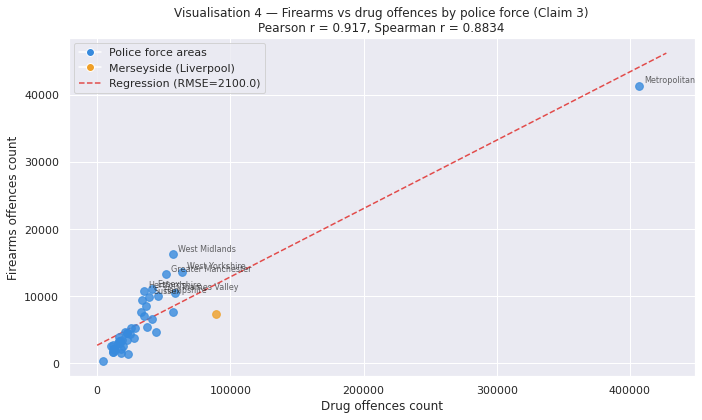

In [26]:
pdf_corr = df_corr.toPandas()

x_line = np.linspace(0, pdf_corr['DrugsCount'].max() * 1.05, 100)
y_line = m * x_line + b

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in pdf_corr.iterrows():
    is_mersey = 'Merseyside' in str(row['Falls_within'])
    ax.scatter(row['DrugsCount'], row['FirearmsCount'],
               color='#EF9F27' if is_mersey else '#378ADD',
               s=60, alpha=0.8, zorder=3)


ax.plot(x_line, y_line, color='#E24B4A', linewidth=1.5,
        linestyle='--', label='Regression line (RMSE={:.1f})'.format(rmse))

for _, row in pdf_corr.iterrows():
    if row['FirearmsCount'] > pdf_corr['FirearmsCount'].quantile(0.8):
        label = str(row['Falls_within']) \
            .replace(' Constabulary','') \
            .replace(' Police Service','') \
            .replace(' Police','')
        ax.annotate(label, (row['DrugsCount'], row['FirearmsCount']),
                    fontsize=8, alpha=0.7,
                    xytext=(5, 3), textcoords='offset points')

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#378ADD',
           markersize=8, label='Police force areas'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#EF9F27',
           markersize=8, label='Merseyside (Liverpool)'),
    Line2D([0], [0], color='#E24B4A', linestyle='--',
           label='Regression (RMSE={:.1f})'.format(rmse))
]
ax.legend(handles=legend_elements)
ax.set_xlabel('Drug offences count')
ax.set_ylabel('Firearms offences count')
ax.set_title(
    'Visualisation 4 — Firearms vs drug offences by police force (Claim 3)\n'
    'Pearson r = {}, Spearman r = {}'.format(pearson, spearman)
)
plt.tight_layout()
plt.show()

Visualisation 4 shows that areas with more drug crime also have more firearms crime. The correlation scores show a strong positive relationship. The Metropolitan is an outlier because London has a very large population and high crime levels. RMSE shows the model follows the overall pattern well.

### Claim 3 — Conclusion

The result strongly support that claim that firearms crime and drug crime are linked. The Pearson score is 0.91 and the Spearman score is 0.85. Both scores show a strong positive relationship. The visualization 4 also shows a clear upward pattern. The regression line follows the pattern as well. The regression model also shows that when drug crime increases, firearms crime usually increases too. There is a limitation that correlation does not prove cause.

---
## Ethical Discussion

The dataset includes latitude and longitude columns. These columns can create privacy problems because people may work where crimes happened and will know where victims live or work that can lead criminals to know areas that are poorly policed. To solve that the Home Office can change the crime locations to nearby roads instead of showing the exact place but there is still some privacy risk. (Chainey and Ratcliffe, 2005)

I noticed a fact during my analysis that drug and weapons crimes depend a lot on police activity because these types of crime are recorded when police find them. This fact could affect my claim 3 finding that the relationship between drug and weapons.

When I was ranking cities by firearms rate for claim 2. This rankings can be misunderstood or misused. If one city is shown as having a high crime rate, people may worry or unfairly judge that city and its residents. Because of this, crime results should need to explain carefully with full context.

While exploring the dataset, I found that around 40% of records are NULL. This is important because some real firearms cases may not include in the analysis. As a result, the total of firearms may be lower than real number. The dataset is published under the UK Open Government Licence v3.0 that allows the dataset to be used for research and education. The dataset does not include personal information because the records are anonymous.

---
##  Evaluation and Conclusion


I used Apache Spark because the dataset contains 65 million records (Damji et al., 2020) that is too large for tools like Excel or the others. Spark can process large amounts of data much faster than the other tools. This helped me to filter, join, and analyse in minutes instead of hours. One advantage of Spark is that the same code worked on both sample dataset and full dataset on Azure. Hence, large datasets require could platform such as Azure because the local computer don't have enough memory to analyse.

I selected only the datasets needed for analyse. The `all_crimes21_hdr.txt` dataset was used for all three claims and the `LSOA_pop_v2.csv` dataset was only used for claim 2. Other datasets were not needed because police force names and LSOA codes are included in the crime dataset. This helped to keep the analysis faster and reduced memory usage.

**Claim 1** was **false**, I used SARIMA because it helped for time series analysis and showed the burglary crime went down around 50% from 2011 to 2021. However, the data did not pass the stationarity test because of Covid-19 lockdowns.

**Claim 2** was **false** because Merseyside Police (Liverpool) ranked 4th for firearms crime per 100,000 people. I used per capita normalisation because comparing raw crime counts and police force areas of different sizes would be meaningless. Hence, dividing crime counts by population gives a fair. The dataset did not show which offences include firearms so the filter used is only an estimate. Some non-firearm weapon offences might be included. 

**Claim 3** was **true**. It showed a strong relationship. I used both Pearson and Spearman correlation methods. This made the results more reliable and both methods showed a strong positive relationship between drug crime and firearms crime. But the correlation does not prove that one crime causes the other. I also used Linear Regression to predict firearms crime from drug crime.

I included four visualisations according to the assessment brief. Each chart was designed to show the results 
clearly and include useful information. 

Overall, two of three claims were false and the one is true. The project showed why data analysis is important for checking claims and showed how big data tools like Apache Spark can help to analyse very large real world datasets quickly.



---
## References

- Apache Spark (2024). *MLlib documentation*. Available at:
  https://spark.apache.org/docs/latest/ml-guide.html
  [Accessed May 2026].

- Chainey, S. and Ratcliffe, J. (2005). *GIS and crime mapping*.
  Chichester: John Wiley and Sons.

- Damji, J. S., Lee, D., Wenig, B. and Das, T. (2020). *Learning
  Spark: Lightning-fast big data analytics*. 2nd ed. Sebastopol:
  O'Reilly Media.

- Dangeti, P. (2017). *Statistics for machine learning: Techniques
  for exploring supervised, unsupervised, and reinforcement learning
  models with Python and R*. Birmingham: Packt Publishing.

- Home Office (2021). *Street level crime data*. Open Government
  Licence v3.0. Available at: https://data.police.uk
  [Accessed May 2026].
  
- Institute for Government (2021). Timeline of UK Coronavirus lockdowns, March 2020 to March 2021. [online] www.instituteforgovernment.org.uk. Available at: https://www.instituteforgovernment.org.uk/sites/default/files/timeline-lockdown-web.pdf.

- Merseyside Police (2024). *About Merseyside Police*. Available at:
  https://www.merseyside.police.uk [Accessed May 2026].

- Nielsen, A. (2019). *Practical time series analysis: Prediction
  with statistics and machine learning*. Sebastopol: O'Reilly Media.

- Office for National Statistics (2011). *Lower Super Output Area
  population estimates*. Available at: https://www.ons.gov.uk
  [Accessed May 2026].

- statsmodels (2024). *Time series analysis*. Available at:
  https://www.statsmodels.org/stable/tsa.html
  [Accessed May 2026].

In [27]:
spark.stop()
print('Spark session stopped.')

Spark session stopped.
